# DATA266 Task 1, GPT Style Character Level LLM From Scratch

**Member:** Anees Saheba · **Dataset:** TinyStories · **Team 8**

A decoder only Transformer trained to predict the next *character*. Every component
, multihead self attention, causal masking, the feedforward block, layer
normalisation and the residual connections, is implemented directly with tensor
operations. No `nn.Transformer`, no `nn.MultiheadAttention`, and no
`F.scaled_dot_product_attention`, as the brief requires.

Configuration follows the team handoff (`task1_llm/team_handoff_yashashree.md`),
which fixes a model distinct from the other member's: 4 layers at width 256 with
4 heads and a 128-character context, against their 6 layers at width 192 with 3
heads and a 256-character context.


In [1]:
import os
import csv
import json
import math
import time
import random
import platform
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("PyTorch:", torch.__version__)
print("Python :", platform.python_version())

PyTorch: 2.14.0
Python : 3.11.8


In [2]:
# Configuration. Every value the run depends on lives here, so a result can be
# traced back to the exact settings that produced it.

SEED = 5330 # last four digits of my student ID

# Data
TRAIN_SEQUENCES = 100_000
VALIDATION_SEQUENCES = 10_000
BLOCK_SIZE = 128 # characters of context the model can attend over
REPAIR_MOJIBAKE = True # see the preprocessing cell for what this does and why

# Architecture
N_LAYERS = 4
D_MODEL = 256
N_HEADS = 4
HEAD_DIM = D_MODEL // N_HEADS
D_FF = 1024
DROPOUT = 0.10

# Optimisation
BATCH_SIZE = 64
EPOCHS = int(os.environ.get("DATA266_EPOCHS", 10)) # brief requires >= 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 1000
GRADIENT_CLIP = 1.0

# Generation
TEMPERATURE = 0.8
GENERATION_LENGTH = 300

assert D_MODEL % N_HEADS == 0, "d_model must divide evenly into the heads"
assert HEAD_DIM == 64, f"expected head dimension 64, got {HEAD_DIM}"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    DEVICE_NAME = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    DEVICE_NAME = "Apple Silicon GPU (MPS)"
else:
    DEVICE = torch.device("cpu")
    DEVICE_NAME = "CPU"

print(f"seed={SEED} device={DEVICE} ({DEVICE_NAME})")
print(f"block_size={BLOCK_SIZE} layers={N_LAYERS} d_model={D_MODEL} "
      f"heads={N_HEADS} head_dim={HEAD_DIM} d_ff={D_FF} dropout={DROPOUT}")

seed=5330 device=mps (Apple Silicon GPU (MPS))
block_size=128 layers=4 d_model=256 heads=4 head_dim=64 d_ff=1024 dropout=0.1


In [3]:
# Output locations, anchored to this member's folder in the repo so results land
# where the brief grades them regardless of where the notebook was launched.
MEMBER_NAME = "anees_saheba"


def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".git").exists() and (candidate / "task1_llm").is_dir():
            return candidate
    return None


REPO_ROOT = find_repo_root()
if REPO_ROOT is not None:
    MEMBER_ROOT = REPO_ROOT / "task1_llm" / MEMBER_NAME
    DATA_FILE = REPO_ROOT / "task1_llm" / "data" / "TinyStories-sample.txt"
    RAW_LOG_DIR = REPO_ROOT / "reproducibility" / "raw_logs"
else:
    MEMBER_ROOT = Path.cwd() / "task1_output"
    DATA_FILE = Path(os.environ.get("DATA266_TINYSTORIES", "TinyStories-sample.txt"))
    RAW_LOG_DIR = MEMBER_ROOT / "raw_logs"

DATA_FILE = Path(os.environ.get("DATA266_TINYSTORIES", DATA_FILE))
CHECKPOINT_DIR = MEMBER_ROOT / "checkpoints"
OUTPUT_DIR = MEMBER_ROOT / "outputs"
PROCESSED_DIR = MEMBER_ROOT / "data_processed"
for folder in (CHECKPOINT_DIR, OUTPUT_DIR, PROCESSED_DIR, RAW_LOG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

RUN_ID = time.strftime("%Y%m%d_%H%M%S")
RAW_LOG_PATH = RAW_LOG_DIR / f"task1_gpt_{RUN_ID}.log"


def log_line(message):
    """Append one timestamped line to the raw log and echo it.

    Flushed on every write so an interrupted session still leaves a usable
    record. This file is the evidence trail and is never edited after the run.
    """
    stamped = f"{time.strftime('%Y-%m-%d %H:%M:%S')} {message}"
    print(stamped)
    with RAW_LOG_PATH.open("a", encoding="utf-8") as handle:
        handle.write(stamped + "\n")
        handle.flush()


if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"TinyStories file not found at {DATA_FILE}.\n"
        "Run: bash scripts/download_data.sh task1\n"
        "or set DATA266_TINYSTORIES to its path."
    )

log_line(f"run_id={RUN_ID} device={DEVICE} ({DEVICE_NAME}) seed={SEED}")
log_line(f"layers={N_LAYERS} d_model={D_MODEL} heads={N_HEADS} d_ff={D_FF} "
         f"block={BLOCK_SIZE} dropout={DROPOUT} lr={LEARNING_RATE} "
         f"batch={BATCH_SIZE} epochs={EPOCHS} warmup={WARMUP_STEPS}")
print("Data file:", DATA_FILE)
print("Raw log :", RAW_LOG_PATH)

2026-10-04 21:25:29 run_id=20261004_212529 device=mps (Apple Silicon GPU (MPS)) seed=5330
2026-10-04 21:25:29 layers=4 d_model=256 heads=4 d_ff=1024 block=128 dropout=0.1 lr=0.0003 batch=64 epochs=10 warmup=1000
Data file: /Users/anees/Documents/Coursework/DATA 266/Lab 1/task1_llm/data/TinyStories-sample.txt
Raw log : /Users/anees/Documents/Coursework/DATA 266/Lab 1/reproducibility/raw_logs/task1_gpt_20261004_212529.log


## 1. Data preprocessing

### 1.1 Loading and the encoding repair

TinyStories as distributed contains mojibake: text encoded as UTF 8 and then
decoded as Latin 1, so a single curly quote `'` became the three characters
`â€™`. Measured on this sample, `â` and `€` each occur exactly 6,353 times,
identical counts, which is the signature of that substitution rather than a
coincidence.

`REPAIR_MOJIBAKE` reverses it by reencoding through Latin 1. The alternative is
to keep the raw text and let the model spend vocabulary entries and capacity on
sequences that only exist because of a decoding error. Repairing is the choice
made here; set the flag to `False` to train on the raw text instead and compare.


In [4]:
raw_text = DATA_FILE.read_text(encoding="utf-8")
print(f"raw characters: {len(raw_text):,}")


# The corruption is UTF 8 decoded as cp1252, not Latin 1: the replacement
# characters include U+20AC, U+0153 and U+2122, which exist in cp1252 only.
#
# A round trip through cp1252 cannot undo it, because U+201D (the closing
# double quote) encodes to byte 0x9D, which is undefined in cp1252 and was
# dropped when the text was first decoded. That byte is gone, so a bare
# "\u00e2\u20ac" with nothing after it is a closing quote with no third byte
# to recover. It is therefore mapped explicitly below.
#
# Targets are ASCII. A character level model pays for every vocabulary entry in
# the output projection, and a curly quote carries no information a straight
# quote does not. Measured effect on this sample: vocabulary 100 -> 91 distinct
# characters, with no new characters introduced.
MOJIBAKE_MAP = [
    ("\u00e2\u20ac\u0153", '"'), # left double quote
    ("\u00e2\u20ac\u2122", "'"), # right single quote / apostrophe
    ("\u00e2\u20ac\u02dc", "'"), # left single quote
    ("\u00e2\u20ac\u201c", "-"), # en dash
    ("\u00e2\u20ac\u201d", "-"), # em dash
    ("\u00e2\u20ac\u00a6", "..."), # ellipsis
    ("\u00e2\u20ac", '"'), # closing double quote, third byte lost
    ("\u00c2", ""), # stray nonbreaking space artifact
]


def repair_mojibake(text):
    """Replace known UTF 8 as cp1252 artifacts with their ASCII equivalents.

    Order matters: the three character sequences are replaced before the bare
    two character one, otherwise every sequence would match the short rule
    first and lose its third character.
    """
    for corrupted, replacement in MOJIBAKE_MAP:
        text = text.replace(corrupted, replacement)
    return text


if REPAIR_MOJIBAKE:
    before_vocab = len(set(raw_text))
    text = repair_mojibake(raw_text)
    print(f"mojibake repair: vocabulary {before_vocab} -> {len(set(text))} distinct characters")
    remaining = sum(text.count(ch) for ch in "\u00e2\u20ac\u0153\u2122\u00c2")
    print(f"remaining mojibake markers: {remaining} (should be 0)")
else:
    text = raw_text
    print("mojibake repair: disabled, training on raw text")

print(f"characters after preprocessing: {len(text):,}")

raw characters: 18,210,906


mojibake repair: vocabulary 100 -> 91 distinct characters


remaining mojibake markers: 0 (should be 0)
characters after preprocessing: 18,200,448


### 1.2 Character vocabulary

The model cannot read characters, only integers, so every distinct character is
assigned an index. `char_to_idx` and `idx_to_char` are built here rather than
taken from a library, as the brief requires. Vocabulary size matters directly:
the language modelling head outputs one score per vocabulary entry, so it sets
the width of the final projection.


In [5]:
vocabulary = sorted(set(text))
VOCAB_SIZE = len(vocabulary)

char_to_idx = {character: index for index, character in enumerate(vocabulary)}
idx_to_char = {index: character for character, index in char_to_idx.items()}

assert all(idx_to_char[char_to_idx[c]] == c for c in vocabulary), "encode/decode mismatch"

counts = Counter(text)
print(f"vocabulary size: {VOCAB_SIZE}")
print("\n10 most frequent characters:")
for character, count in counts.most_common(10):
    label = {" ": "'space'", "\n": "\\n"}.get(character, repr(character))
    print(f" {label:<9} {count:>10,} {100 * count / len(text):>6.3f}%")
print("\n10 least frequent characters:")
for character, count in counts.most_common()[-10:]:
    print(f" {repr(character):<9} {count:>10,} {100 * count / len(text):>6.4f}%")

with (PROCESSED_DIR / "vocabulary.json").open("w", encoding="utf-8") as handle:
    json.dump({"vocab_size": VOCAB_SIZE,
               "char_to_idx": char_to_idx,
               "repair_mojibake": REPAIR_MOJIBAKE}, handle, ensure_ascii=False, indent=1)
log_line(f"vocab_size={VOCAB_SIZE} repair_mojibake={REPAIR_MOJIBAKE}")

vocabulary size: 91

10 most frequent characters:
 'space'    3,412,476 18.749%
 'e'        1,720,456  9.453%
 'a'        1,201,529  6.602%
 't'        1,136,031  6.242%
 'o'          974,366  5.354%
 'h'          876,716  4.817%
 'n'          855,246  4.699%
 'd'          785,815  4.318%
 'i'          770,628  4.234%
 's'          757,412  4.162%

10 least frequent characters:
 '/'                3 0.0000%
 '8'                2 0.0000%
 '$'                2 0.0000%
 '¡'                2 0.0000%
 '³'                1 0.0000%
 '&'                1 0.0000%
 '+'                1 0.0000%
 '\xa0'             1 0.0000%
 '('                1 0.0000%
 ')'                1 0.0000%


2026-10-04 21:25:29 vocab_size=91 repair_mojibake=True


### 1.3 Input to target sequences and the split

Autoregressive training needs, for every position, the character that follows it.
A window of `BLOCK_SIZE + 1` characters supplies both at once:

```
window : O n c e u p o n a t i m
input : O n c e u p o n a t i (window[:-1])
target : n c e u p o n a t i m (window[1:])
```

The same sequence shifted by one position. Position *i* of the input predicts
position *i* of the target, so one window yields `BLOCK_SIZE` training signals
rather than one.

Windows are cut **nonoverlapping**, then shuffled with this member's seed and
split. Because no two windows share a character, no validation text appears
anywhere in training, overlapping windows would leak and make validation loss
look better than it is.


In [6]:
encoded = np.fromiter((char_to_idx[c] for c in text), dtype=np.int64, count=len(text))

WINDOW = BLOCK_SIZE + 1
n_windows = len(encoded) // WINDOW
windows = encoded[: n_windows * WINDOW].reshape(n_windows, WINDOW)

required = TRAIN_SEQUENCES + VALIDATION_SEQUENCES
if n_windows < required:
    raise RuntimeError(
        f"Only {n_windows:,} nonoverlapping windows available but {required:,} needed. "
        f"Download more data: TINYSTORIES_N=40000 bash scripts/download_data.sh task1"
    )

split_rng = np.random.default_rng(SEED)
permutation = split_rng.permutation(n_windows)
train_indices = permutation[:TRAIN_SEQUENCES]
validation_indices = permutation[TRAIN_SEQUENCES:required]

assert not (set(train_indices.tolist()) & set(validation_indices.tolist())), "splits overlap"

train_windows = windows[train_indices]
validation_windows = windows[validation_indices]

print(f"windows available : {n_windows:,}")
print(f"train sequences : {len(train_windows):,}")
print(f"validation : {len(validation_windows):,}")
print(f"characters used : {required * WINDOW:,} of {len(encoded):,}")

print("\nOne example, decoded:")
example = train_windows[0]
print(" input :", repr("".join(idx_to_char[i] for i in example[:-1])[:60]) + " ...")
print(" target:", repr("".join(idx_to_char[i] for i in example[1:])[:60]) + " ...")

np.save(PROCESSED_DIR / "train_windows.npy", train_windows)
np.save(PROCESSED_DIR / "validation_windows.npy", validation_windows)
log_line(f"train_sequences={len(train_windows)} validation_sequences={len(validation_windows)} "
         f"window={WINDOW} total_windows={n_windows}")

windows available : 141,088
train sequences : 100,000
validation : 10,000
characters used : 14,190,000 of 18,200,448

One example, decoded:
 input : 'l morning. They are very sleepy. They wish they did not prev' ...
 target: ' morning. They are very sleepy. They wish they did not preve' ...
2026-10-04 21:25:30 train_sequences=100000 validation_sequences=10000 window=129 total_windows=141088


In [7]:
class CharSequenceDataset(Dataset):
    """Returns (input, target) pairs: the same window shifted by one position."""

    def __init__(self, windows):
        self.windows = torch.from_numpy(np.ascontiguousarray(windows))

    def __len__(self):
        return self.windows.shape[0]

    def __getitem__(self, index):
        window = self.windows[index]
        return window[:-1], window[1:]


train_dataset = CharSequenceDataset(train_windows)
validation_dataset = CharSequenceDataset(validation_windows)

# Workers only help on CUDA; under Jupyter on macOS spawned workers cannot
# unpickle a Dataset defined in a notebook cell.
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
                          generator=loader_generator, drop_last=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")

x_example, y_example = next(iter(train_loader))
print(f"batch input shape : {tuple(x_example.shape)}")
print(f"batch target shape: {tuple(y_example.shape)}")
print(f"train batches : {len(train_loader):,}")
print(f"validation batches: {len(validation_loader):,}")
print(f"optimiser steps : {len(train_loader) * EPOCHS:,} over {EPOCHS} epochs")

batch input shape : (64, 128)
batch target shape: (64, 128)
train batches : 1,562
validation batches: 157
optimiser steps : 15,620 over 10 epochs


## 2. Model

Built from tensor operations only. `nn.Linear`, `nn.Embedding`, `nn.LayerNorm`
and `nn.Dropout` are plain layers, not Transformer or attention modules; the
attention itself is written out below.

### What self attention computes

Each position produces three vectors from its own embedding:

- **Query**, what this position is looking for
- **Key**, what this position offers
- **Value**, what this position contributes if attended to

The score between positions *i* and *j* is `q_i · k_j`. Softmax over *j* turns
those scores into weights summing to 1, and the output at *i* is the
weighted sum of values. So "attention" is: *compare my query against every key,
then mix the values in proportion.*

**Why divide by √head_dim.** The dot product of two `head_dim`-dimensional
vectors with unit variance entries has variance `head_dim`. At `head_dim = 64`
raw scores reach ±8 or beyond, and softmax of values that large is nearly
one hot with almost no gradient. Dividing by `√64 = 8` restores unit variance
and keeps softmax in a range where it can still learn.

**Why multiple heads.** One attention operation produces a single weighted
average, so it can only express one notion of relevance at a time. Four heads
of 64 dimensions cost the same as one head of 256, but each can specialise,
one tracking the immediately preceding character, another the position after an
opening quote. They are concatenated and mixed by the output projection.

**Causal masking.** Position *i* must never see position *j > i*: at training
time the target is the next character, so attending forward would let the model
read the answer and it would learn nothing useful for generation. Scores above
the diagonal are set to `-inf` **before** softmax, so `exp(-inf) = 0` and those
weights are exactly zero. Masking after softmax would leave the denominator
contaminated by future positions.


In [8]:
class CausalSelfAttention(nn.Module):
    """Multihead self attention with causal masking, written from scratch."""

    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # Q, K and V for every head in one projection. Mathematically identical
        # to three separate Linear layers; one matmul instead of three.
        self.qkv_projection = nn.Linear(d_model, 3 * d_model)
        self.output_projection = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(dropout)
        self.residual_dropout = nn.Dropout(dropout)

        # Lower triangular matrix: row i has ones in columns 0..i. Registered as
        # a buffer so it moves with .to(device) but is not a learned parameter.
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size),
            persistent=False,
        )

    def forward(self, x, return_attention=False):
        batch, seq_len, d_model = x.shape

        qkv = self.qkv_projection(x)
        query, key, value = qkv.split(d_model, dim=2)

        # (batch, seq, d_model) -> (batch, heads, seq, head_dim) so each head
        # attends independently.
        def to_heads(tensor):
            return tensor.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        query, key, value = to_heads(query), to_heads(key), to_heads(value)

        # Scaled dot product attention, written out rather than called.
        scores = (query @ key.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Mask BEFORE softmax so future positions get exactly zero weight.
        scores = scores.masked_fill(self.causal_mask[:, :, :seq_len, :seq_len] == 0,
                                    float("-inf"))
        attention = F.softmax(scores, dim=-1)
        attention = self.attention_dropout(attention)

        out = attention @ value # (batch, heads, seq, head_dim)
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, d_model)
        out = self.residual_dropout(self.output_projection(out))

        if return_attention:
            return out, attention
        return out


class FeedForward(nn.Module):
    """Position wise MLP: expand, apply a nonlinearity, project back.

    Attention mixes information across positions but is linear in the values.
    This is where per position nonlinear transformation happens. The 4x
    expansion (256 -> 1024 -> 256) follows Vaswani et al.
    """

    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Pre LayerNorm Transformer block.

    Pre norm (normalise before the sublayer, add the raw residual) rather than
    the original post norm: it keeps an unnormalised identity path from input to
    output, so gradients reach early layers directly and training is stable
    without a long warmup. Post norm places LayerNorm on that path and is
    noticeably harder to train at depth.
    """

    def __init__(self, d_model, n_heads, d_ff, block_size, dropout):
        super().__init__()
        self.norm_attention = nn.LayerNorm(d_model)
        self.attention = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.norm_feedforward = nn.LayerNorm(d_model)
        self.feedforward = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attention(self.norm_attention(x))
        x = x + self.feedforward(self.norm_feedforward(x))
        return x


class CharGPT(nn.Module):
    """Decoder only Transformer for character level language modelling."""

    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, block_size, dropout):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # Learned, not sinusoidal: attention alone is permutation invariant, so
        # without this the model could not tell "abc" from "cba".
        self.position_embedding = nn.Embedding(block_size, d_model)
        self.embedding_dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, block_size, dropout)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        # N(0, 0.02) as in GPT-2. Default PyTorch init scales with fan in and
        # gives larger initial logits, which makes early training noisier.
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        batch, seq_len = idx.shape
        if seq_len > self.block_size:
            raise ValueError(f"sequence length {seq_len} exceeds block size {self.block_size}")

        positions = torch.arange(seq_len, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(positions)
        x = self.embedding_dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss


model = CharGPT(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, BLOCK_SIZE, DROPOUT).to(DEVICE)

PARAMETER_COUNT = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\ntrainable parameters: {PARAMETER_COUNT:,}")
for name, module in (("token embedding", model.token_embedding),
                     ("position embedding", model.position_embedding),
                     ("lm head", model.lm_head)):
    print(f" {name:<20} {sum(p.numel() for p in module.parameters()):>10,}")
print(f" {'per block':<20} {sum(p.numel() for p in model.blocks[0].parameters()):>10,}"
      f" x {N_LAYERS} layers")
log_line(f"parameter_count={PARAMETER_COUNT}")

CharGPT(
  (token_embedding): Embedding(91, 256)
  (position_embedding): Embedding(128, 256)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm_attention): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): CausalSelfAttention(
        (qkv_projection): Linear(in_features=256, out_features=768, bias=True)
        (output_projection): Linear(in_features=256, out_features=256, bias=True)
        (attention_dropout): Dropout(p=0.1, inplace=False)
        (residual_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm_feedforward): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (feedforward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
       

### 2.1 Verifying the causal mask

The mask is the single place where a silent bug would invalidate the whole task:
a model that can see the next character learns to copy it, and reports an
excellent loss that means nothing. Two checks below.

**Direct check**, attention weights to future positions must be exactly `0.0`,
not merely small.

**Behavioural check**, changing a character at position *t* must leave outputs
at positions `< t` bit identical. If a later character can influence an earlier
prediction, information is flowing backwards in time.


In [9]:
model.eval()
with torch.no_grad():
    probe = x_example[:2].to(DEVICE)
    block = model.blocks[0]
    normalised = block.norm_attention(
        model.embedding_dropout(
            model.token_embedding(probe)
            + model.position_embedding(torch.arange(probe.shape[1], device=DEVICE))
        )
    )
    _, attention_weights = block.attention(normalised, return_attention=True)

seq_len = attention_weights.shape[-1]
future = torch.triu(torch.ones(seq_len, seq_len, device=attention_weights.device),
                    diagonal=1).bool()
future_mass = attention_weights[:, :, future].abs().max().item()
row_sums = attention_weights.sum(dim=-1)

print(f"attention tensor shape : {tuple(attention_weights.shape)} (batch, heads, seq, seq)")
print(f"max weight on a FUTURE position: {future_mass:.3e} <- must be exactly 0.0")
print(f"row sums min/max : {row_sums.min():.6f} / {row_sums.max():.6f} <- must be 1.0")
print(f"position 0 attends to : {(attention_weights[0, 0, 0] > 0).sum().item()} position(s)")
print(f"position {seq_len-1} attends to : {(attention_weights[0, 0, -1] > 0).sum().item()} position(s)")
assert future_mass == 0.0, "FAIL: attention leaks into future positions"

# Behavioural check: perturb the last position, earlier logits must not move.
with torch.no_grad():
    original = probe.clone()
    modified = probe.clone()
    modified[:, -1] = (modified[:, -1] + 1) % VOCAB_SIZE
    logits_original, _ = model(original)
    logits_modified, _ = model(modified)

difference = (logits_original[:, :-1] - logits_modified[:, :-1]).abs().max().item()
print(f"\nchanged the final input character; max change in EARLIER logits: {difference:.3e}")
assert difference == 0.0, "FAIL: a later character changed an earlier prediction"
print("\nCausal masking verified: no future information reaches any position.")
log_line(f"causal_mask_verified future_mass={future_mass} earlier_logit_delta={difference}")

attention tensor shape : (2, 4, 128, 128) (batch, heads, seq, seq)
max weight on a FUTURE position: 0.000e+00 <- must be exactly 0.0
row sums min/max : 1.000000 / 1.000000 <- must be 1.0
position 0 attends to : 1 position(s)
position 127 attends to : 128 position(s)

changed the final input character; max change in EARLIER logits: 0.000e+00

Causal masking verified: no future information reaches any position.
2026-10-04 21:25:31 causal_mask_verified future_mass=0.0 earlier_logit_delta=0.0


## 3. Training

### Why warmup, and why cosine afterwards

At step 0 the weights are random, so the first gradients point in essentially
arbitrary directions. Applying the full learning rate to them moves the model a
long way for no reason, and Adam compounds this: its second moment estimate
starts near zero, so early updates are divided by a very small number and become
large. Transformers are particularly sensitive because LayerNorm statistics
shift under big updates.

Warmup ramps the rate linearly from ~0 over the first 1,000 steps, letting
Adam's moment estimates stabilise before any large step is taken. After that,
cosine decay anneals smoothly to a small floor so late training refines rather
than bounces. Both are required by §1.3.2.


In [10]:
TOTAL_STEPS = len(train_loader) * EPOCHS
MIN_LR_RATIO = 0.10 # cosine floor, as a fraction of peak


def learning_rate_at(step):
    """Linear warmup for WARMUP_STEPS, then cosine decay to MIN_LR_RATIO."""
    if step < WARMUP_STEPS:
        return LEARNING_RATE * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    progress = min(1.0, progress)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return LEARNING_RATE * (MIN_LR_RATIO + (1 - MIN_LR_RATIO) * cosine)


# Decay applies to matmul weights only. Biases, LayerNorm parameters and
# embeddings are excluded: shrinking them toward zero fights the normalisation
# rather than regularising the function the model computes.
decay_parameters, no_decay_parameters = [], []
for name, parameter in model.named_parameters():
    if not parameter.requires_grad:
        continue
    if parameter.ndim < 2 or "norm" in name or "embedding" in name:
        no_decay_parameters.append(parameter)
    else:
        decay_parameters.append(parameter)

optimizer = torch.optim.AdamW(
    [{"params": decay_parameters, "weight_decay": WEIGHT_DECAY},
     {"params": no_decay_parameters, "weight_decay": 0.0}],
    lr=LEARNING_RATE, betas=(0.9, 0.95), eps=1e-8,
)

print(f"total optimiser steps : {TOTAL_STEPS:,}")
print(f"warmup steps : {WARMUP_STEPS:,} ({100*WARMUP_STEPS/TOTAL_STEPS:.1f}% of training)")
print(f"decayed tensors : {len(decay_parameters)} ({sum(p.numel() for p in decay_parameters):,} params)")
print(f"nondecayed tensors : {len(no_decay_parameters)} ({sum(p.numel() for p in no_decay_parameters):,} params)")
schedule = [learning_rate_at(s) for s in range(TOTAL_STEPS)]
print(f"learning rate: start {schedule[0]:.2e} peak {max(schedule):.2e} end {schedule[-1]:.2e}")

total optimiser steps : 15,620
warmup steps : 1,000 (6.4% of training)
decayed tensors : 17 (3,169,024 params)
nondecayed tensors : 36 (69,888 params)
learning rate: start 3.00e-07 peak 3.00e-04 end 3.00e-05


In [11]:
@torch.no_grad()
def evaluate(loader, max_batches=None):
    """Mean cross entropy and top 1 next character accuracy over a loader."""
    model.eval()
    total_loss, total_correct, total_tokens, batches = 0.0, 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        logits, loss = model(inputs, targets)
        total_loss += loss.item()
        total_correct += (logits.argmax(dim=-1) == targets).sum().item()
        total_tokens += targets.numel()
        batches += 1
        if max_batches is not None and batches >= max_batches:
            break
    model.train()
    return total_loss / batches, total_correct / total_tokens


def reset_peak_memory():
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()


def peak_memory_gb():
    """CUDA reports a true peak; MPS reports current allocation, not a high water mark."""
    if DEVICE.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1024 ** 3
    if DEVICE.type == "mps":
        return torch.mps.driver_allocated_memory() / 1024 ** 3
    return 0.0


print("evaluation helpers ready")

evaluation helpers ready


In [12]:
history = {"train_loss": [], "validation_loss": [], "validation_accuracy": [],
           "epoch_seconds": [], "tokens_per_second": [], "learning_rate": [],
           "gradient_norm_mean": [], "gradient_norm_max": []}

# Stability tracking, required by the metrics list.
gradient_norms = []
loss_spikes = [] # a step whose loss jumps >50% above a running average
nan_or_inf_steps = 0
recent_losses = []

best_validation_loss = float("inf")
global_step = 0
reset_peak_memory()
training_start = time.perf_counter()
log_line(f"TRAINING START total_steps={TOTAL_STEPS} parameters={PARAMETER_COUNT}")

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()
    epoch_loss, epoch_batches, epoch_tokens = 0.0, 0, 0
    epoch_gradient_norms = []

    for inputs, targets in train_loader:
        learning_rate = learning_rate_at(global_step)
        for group in optimizer.param_groups:
            group["lr"] = learning_rate

        inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
        _, loss = model(inputs, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP).item()
        optimizer.step()

        loss_value = loss.item()
        if not math.isfinite(loss_value) or not math.isfinite(gradient_norm):
            nan_or_inf_steps += 1
            log_line(f"WARNING nonfinite at step {global_step}: loss={loss_value} grad={gradient_norm}")
        else:
            recent_losses.append(loss_value)
            if len(recent_losses) > 100:
                recent_losses.pop(0)
            if len(recent_losses) == 100 and loss_value > 1.5 * (sum(recent_losses) / len(recent_losses)):
                loss_spikes.append({"step": global_step, "loss": loss_value})
                log_line(f"LOSS SPIKE step={global_step} loss={loss_value:.4f}")

        epoch_loss += loss_value
        epoch_batches += 1
        epoch_tokens += targets.numel()
        gradient_norms.append(gradient_norm)
        epoch_gradient_norms.append(gradient_norm)

        if global_step % 200 == 0:
            log_line(f"step {global_step}/{TOTAL_STEPS} loss={loss_value:.4f} "
                     f"grad_norm={gradient_norm:.4f} lr={learning_rate:.3e}")
        global_step += 1

    epoch_seconds = time.perf_counter() - epoch_start
    train_loss = epoch_loss / epoch_batches
    validation_loss, validation_accuracy = evaluate(validation_loader)
    tokens_per_second = epoch_tokens / epoch_seconds

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["epoch_seconds"].append(epoch_seconds)
    history["tokens_per_second"].append(tokens_per_second)
    history["learning_rate"].append(learning_rate)
    history["gradient_norm_mean"].append(float(np.mean(epoch_gradient_norms)))
    history["gradient_norm_max"].append(float(np.max(epoch_gradient_norms)))

    log_line(f"EPOCH {epoch}/{EPOCHS} train_loss={train_loss:.4f} val_loss={validation_loss:.4f} "
             f"val_acc={validation_accuracy:.4f} ppl={math.exp(validation_loss):.3f} "
             f"bpc={validation_loss/math.log(2):.4f} gap={validation_loss - train_loss:+.4f} "
             f"grad_mean={np.mean(epoch_gradient_norms):.4f} seconds={epoch_seconds:.1f} "
             f"tokens_per_sec={tokens_per_second:.0f} peak_gb={peak_memory_gb():.3f}")

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save({"epoch": epoch, "seed": SEED, "model": model.state_dict(),
                    "vocab_size": VOCAB_SIZE, "char_to_idx": char_to_idx,
                    "config": {"n_layers": N_LAYERS, "d_model": D_MODEL, "n_heads": N_HEADS,
                               "d_ff": D_FF, "block_size": BLOCK_SIZE, "dropout": DROPOUT},
                    "validation_loss": validation_loss},
                   CHECKPOINT_DIR / "best_model.pt")
        log_line(f"CHECKPOINT best_model.pt at epoch {epoch} val_loss={validation_loss:.4f}")

TOTAL_TRAINING_TIME = time.perf_counter() - training_start
PEAK_MEMORY_GB = peak_memory_gb()
log_line(f"TRAINING COMPLETE seconds={TOTAL_TRAINING_TIME:.1f} "
         f"best_val_loss={best_validation_loss:.4f} spikes={len(loss_spikes)} nan_steps={nan_or_inf_steps}")

with (OUTPUT_DIR / "training_history.json").open("w") as handle:
    json.dump(history, handle, indent=2)

2026-10-04 21:25:31 TRAINING START total_steps=15620 parameters=3238912


2026-10-04 21:25:31 step 0/15620 loss=4.4729 grad_norm=6.4744 lr=3.000e-07


2026-10-04 21:25:59 step 200/15620 loss=2.5469 grad_norm=0.7618 lr=6.030e-05


2026-10-04 21:26:25 step 400/15620 loss=2.2297 grad_norm=0.7002 lr=1.203e-04


2026-10-04 21:26:54 step 600/15620 loss=1.9742 grad_norm=1.1952 lr=1.803e-04


...

2026-10-04 22:22:26 step 15000/15620 loss=0.7920 grad_norm=0.6005 lr=3.120e-05


2026-10-04 22:23:09 step 15200/15620 loss=0.8235 grad_norm=0.6025 lr=3.055e-05


2026-10-04 22:23:50 step 15400/15620 loss=0.7865 grad_norm=0.5855 lr=3.015e-05


2026-10-04 22:24:33 step 15600/15620 loss=0.8015 grad_norm=0.5906 lr=3.000e-05


2026-10-04 22:24:48 EPOCH 10/10 train_loss=0.7841 val_loss=0.7538 val_acc=0.7607 ppl=2.125 bpc=1.0875 gap=-0.0303 grad_mean=0.5816 seconds=336.0 tokens_per_sec=38086 peak_gb=1.104
2026-10-04 22:24:48 CHECKPOINT best_model.pt at epoch 10 val_loss=0.7538
2026-10-04 22:24:48 TRAINING COMPLETE seconds=3557.0 best_val_loss=0.7538 spikes=0 nan_steps=0


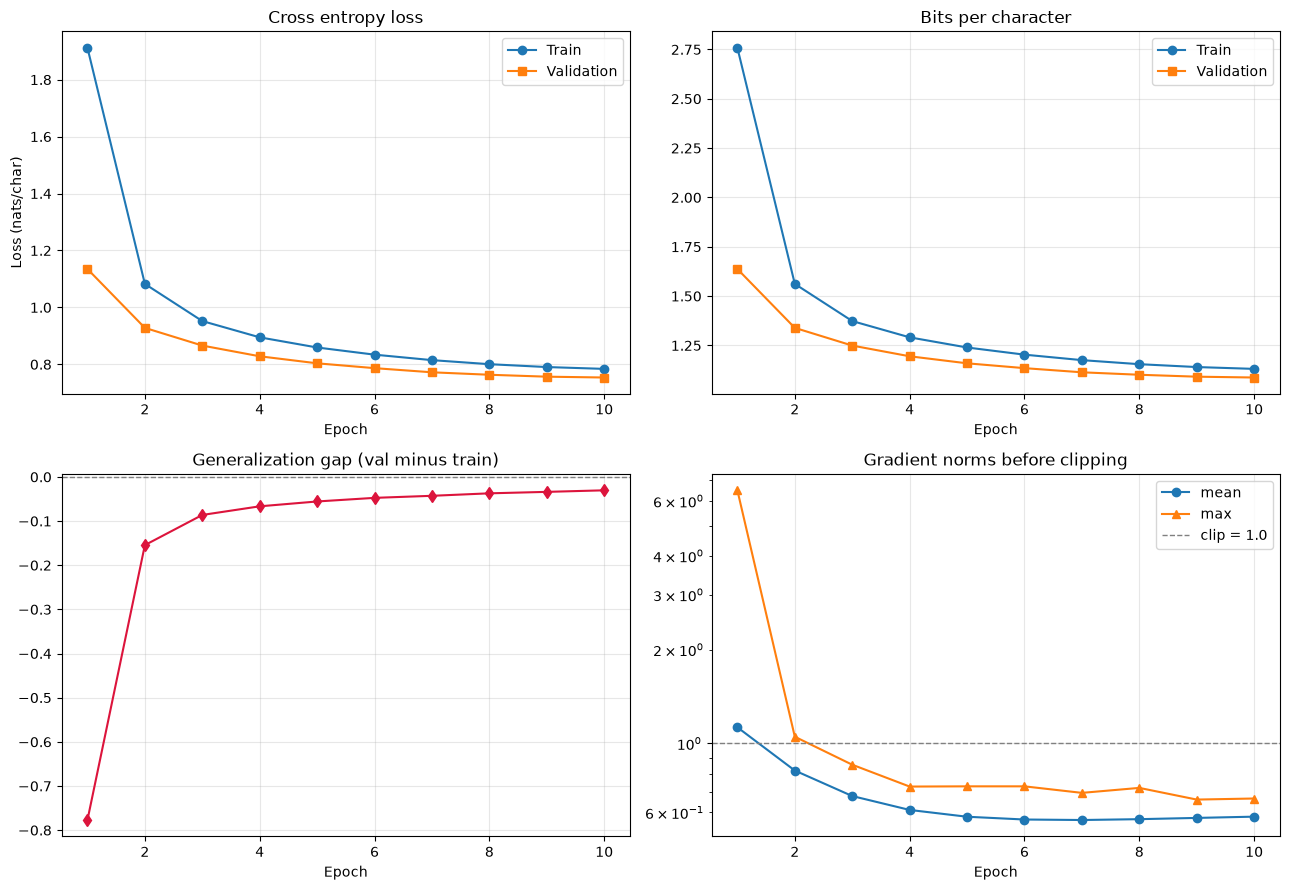

saved: /Users/anees/Documents/Coursework/DATA 266/Lab 1/task1_llm/anees_saheba/outputs/loss_curves.png


In [13]:
epochs_axis = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(epochs_axis, history["train_loss"], marker="o", label="Train")
axes[0, 0].plot(epochs_axis, history["validation_loss"], marker="s", label="Validation")
axes[0, 0].set_title("Cross entropy loss"); axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss (nats/char)"); axes[0, 0].legend(); axes[0, 0].grid(alpha=.3)

axes[0, 1].plot(epochs_axis, [l / math.log(2) for l in history["train_loss"]], marker="o", label="Train")
axes[0, 1].plot(epochs_axis, [l / math.log(2) for l in history["validation_loss"]], marker="s", label="Validation")
axes[0, 1].set_title("Bits per character"); axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend(); axes[0, 1].grid(alpha=.3)

gap = [v - t for t, v in zip(history["train_loss"], history["validation_loss"])]
axes[1, 0].plot(epochs_axis, gap, marker="d", color="crimson")
axes[1, 0].axhline(0, linestyle="--", linewidth=1, color="grey")
axes[1, 0].set_title("Generalization gap (val minus train)"); axes[1, 0].set_xlabel("Epoch")
axes[1, 0].grid(alpha=.3)

axes[1, 1].plot(epochs_axis, history["gradient_norm_mean"], marker="o", label="mean")
axes[1, 1].plot(epochs_axis, history["gradient_norm_max"], marker="^", label="max")
axes[1, 1].axhline(GRADIENT_CLIP, linestyle="--", linewidth=1, color="grey",
                   label=f"clip = {GRADIENT_CLIP}")
axes[1, 1].set_title("Gradient norms before clipping"); axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_yscale("log"); axes[1, 1].legend(); axes[1, 1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=160)
plt.show()
print("saved:", OUTPUT_DIR / "loss_curves.png")

## 4. Text generation

Generation is autoregressive: predict one character, append it to the context,
predict again. Once the context reaches `BLOCK_SIZE` the oldest character is
dropped, since the position embedding table only has `BLOCK_SIZE` entries.

**Greedy** always takes the highest probability character. It is deterministic
and tends to fall into loops, because once a repeating pattern becomes locally
most likely nothing can break it.

**Temperature sampling** divides the logits by `T` before softmax. `T < 1`
sharpens the distribution toward the argmax; `T > 1` flattens it, making rare
characters more likely. At `T -> 0` it becomes greedy. Both are produced below
so the difference can be shown rather than asserted.


In [14]:
@torch.no_grad()
def generate(prompt, max_new_characters=GENERATION_LENGTH, temperature=None, seed=None):
    """Generate continuation text. temperature=None means greedy decoding."""
    if seed is not None:
        torch.manual_seed(seed)
    model.eval()

    unknown = [c for c in prompt if c not in char_to_idx]
    if unknown:
        raise ValueError(f"prompt contains characters outside the vocabulary: {set(unknown)}")

    context = torch.tensor([[char_to_idx[c] for c in prompt]], dtype=torch.long, device=DEVICE)
    generated = []

    start = time.perf_counter()
    for _ in range(max_new_characters):
        # Keep only the last block_size characters: the position embedding
        # table has no entry beyond that.
        window = context[:, -BLOCK_SIZE:]
        logits, _ = model(window)
        next_logits = logits[:, -1, :]

        if temperature is None:
            next_index = next_logits.argmax(dim=-1, keepdim=True)
        else:
            probabilities = F.softmax(next_logits / temperature, dim=-1)
            next_index = torch.multinomial(probabilities, num_samples=1)

        context = torch.cat([context, next_index], dim=1)
        generated.append(next_index.item())

    elapsed = time.perf_counter() - start
    text_out = "".join(idx_to_char[i] for i in generated)
    return text_out, max_new_characters / elapsed


PROMPTS = ["Once upon a time", "The little girl", "One day, Tom"]
samples = []

for prompt in PROMPTS:
    greedy_text, greedy_speed = generate(prompt, temperature=None)
    samples.append({"prompt": prompt, "decoding": "greedy", "temperature": None,
                    "generated": greedy_text, "characters_per_second": greedy_speed})
    print(f"PROMPT: {prompt!r} | GREEDY")
    print(prompt + greedy_text)
    print()

for prompt in PROMPTS:
    for temperature in (0.5, TEMPERATURE, 1.2):
        sampled_text, sampled_speed = generate(prompt, temperature=temperature, seed=SEED)
        samples.append({"prompt": prompt, "decoding": "temperature", "temperature": temperature,
                        "generated": sampled_text, "characters_per_second": sampled_speed})
        print(f"PROMPT: {prompt!r} | TEMPERATURE {temperature}")
        print(prompt + sampled_text)
        print()

GENERATION_SPEED = float(np.mean([s["characters_per_second"] for s in samples]))
print(f"mean generation speed: {GENERATION_SPEED:.1f} characters/sec")

with (OUTPUT_DIR / "generated_samples.json").open("w", encoding="utf-8") as handle:
    json.dump(samples, handle, indent=2, ensure_ascii=False)
with (OUTPUT_DIR / "generated_samples.txt").open("w", encoding="utf-8") as handle:
    for sample in samples:
        label = "greedy" if sample["temperature"] is None else f"temperature={sample['temperature']}"
        handle.write(f"PROMPT: {sample['prompt']!r} | {label}\n")
        handle.write(sample["prompt"] + sample["generated"] + "\n\n")
log_line(f"generation_chars_per_sec={GENERATION_SPEED:.2f} samples={len(samples)}")

PROMPT: 'Once upon a time' | GREEDY
Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, she went to the park with her mommy and daddy. They saw a big boy who was very sad and angry. They wanted to show her mommy how to be careful when they saw the boy was so happy to have a new friend



PROMPT: 'The little girl' | GREEDY
The little girl was so happy to have a new friend to play with. She had a big box of colorful things that she had been so brave and she was so happy to have a new friend.
<|endofstory|>
Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, she went t



PROMPT: 'One day, Tom' | GREEDY
One day, Tom went to the park with his mom. He saw a big storm on the ground. He wanted to see what was inside. He wanted to see what was inside.

"Hello, little boy," said the storm. "I want to go to the store to buy some food," said the storm.

The storm smiled and said, "I want to share you with your friends



PROMPT: 'Once upon a time' | TEMPERATURE 0.5
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine and play in the garden. One day, she wanted to play with her toys to play with her toys. She took her doll and threw it into the box. She saw the toy car and was so happy. She thanked the doll and they both laughed and s



PROMPT: 'Once upon a time' | TEMPERATURE 0.8
Once upon a time, there was a little girl named Lily. She loved to dream on a journal and play all day long. One day she was walking outside to see what a feather that was walking. She saw a big hill and a bowl of colorful blocks. She started to cry.

"Mom, can I have a mouse to stop a very happy so you give them e



...

PROMPT: 'The little girl' | TEMPERATURE 0.8
The little girl felt very sad and angry.

The little girl was so excited. She smiled and said, "Okay, it's okay." She had the little girl never took her off the tree again.
<|endofstory|>
Tom and Lily were playing in the park with their toys and books. They saw a big hole in the yard. The book was scared and wante



PROMPT: 'The little girl' | TEMPERATURE 1.2
The little girl felt very upset and loved her mom and daddy. 

The bear had fun with her comfortable yet. She hugged her and said she would do something she did. She searched back to a cembarrator ran home nervously.

She enjoyed exploring the world. She saw her mom rainbow and said, "Okay, mom. You are hot and me



PROMPT: 'One day, Tom' | TEMPERATURE 0.5
One day, Tom found a big box in his box. It was a small pot of different dress. 

Tom was sad but he couldn't find it. He said he had to stop singing on the ground and walk around and his friends. They were so happy that he had learned that it's important to be careful and get to a very happy she could have hel



PROMPT: 'One day, Tom' | TEMPERATURE 0.8
One day, Tom found a little boy named Tom who loved to play outside. One day, Tom was playing outside when he saw a big, scary dog with a lot of animals. Tom was very happy and said, "Wow, that is what your dog, Bob said, I must rest. We think they are still more red things to do a valuable little boy." 

Zoe n



PROMPT: 'One day, Tom' | TEMPERATURE 1.2
One day, Tom found a little boy named Tom who likes to build walls.

One day, Tom and Tom saw some rainbow on the water. It was so big that their faces that the rabbit wanted to search. But Tom did not want to peek petter. He kept stitting in the mineral and making a hug. He said,
 "Can we catch it?" Both asked

mean generation speed: 233.3 characters/sec
2026-10-04 22:25:04 generation_chars_per_sec=233.30 samples=12


## 5. Evaluation metrics

**Perplexity** is `exp(cross entropy)`: the effective number of characters the
model is choosing between at each step. Perplexity 5 means it is about as
uncertain as picking uniformly among 5 characters. A uniform model over this
vocabulary would score the vocabulary size.

**Bits per character** is the same quantity in base 2, `loss / ln 2`, and is
the standard unit for character level models because it reads directly as
compression: BPC 1.5 means the text could be stored in about 1.5 bits per
character.

**Distinct-1/2/3** is the fraction of generated ngrams that are unique. Low
values mean the model recycles the same fragments. **Repeated 4gram rate** is
the complement: how much of the output is repetition.


In [15]:
def distinct_n(sequence, n):
    """Fraction of ngrams in the text that are unique."""
    if len(sequence) < n:
        return float("nan")
    ngrams = [sequence[i:i + n] for i in range(len(sequence) - n + 1)]
    return len(set(ngrams)) / len(ngrams)


def repeated_ngram_rate(sequence, n=4):
    """Fraction of ngram occurrences that are not the first use of that ngram."""
    if len(sequence) < n:
        return float("nan")
    ngrams = [sequence[i:i + n] for i in range(len(sequence) - n + 1)]
    counts = Counter(ngrams)
    repeated = sum(count - 1 for count in counts.values() if count > 1)
    return repeated / len(ngrams)


# Measured over temperature sampled text at the configured temperature, since
# that is the setting the reported samples use.
diversity_text = "".join(s["generated"] for s in samples
                         if s["temperature"] == TEMPERATURE)
greedy_text_all = "".join(s["generated"] for s in samples if s["temperature"] is None)

final_train_loss = history["train_loss"][-1]
final_validation_loss = history["validation_loss"][-1]
_, final_accuracy = evaluate(validation_loader)

metrics = {
    "train_cross_entropy_loss": final_train_loss,
    "val_cross_entropy_loss": final_validation_loss,
    "best_val_cross_entropy_loss": best_validation_loss,
    "perplexity": math.exp(final_validation_loss),
    "bits_per_character": final_validation_loss / math.log(2),
    "generalization_gap": final_validation_loss - final_train_loss,
    "top1_next_char_accuracy": final_accuracy,
    "distinct_1": distinct_n(diversity_text, 1),
    "distinct_2": distinct_n(diversity_text, 2),
    "distinct_3": distinct_n(diversity_text, 3),
    "repeated_4gram_rate": repeated_ngram_rate(diversity_text, 4),
    "repeated_4gram_rate_greedy": repeated_ngram_rate(greedy_text_all, 4),
    "grad_norm_mean": float(np.mean(gradient_norms)),
    "grad_norm_max": float(np.max(gradient_norms)),
    "grad_norm_median": float(np.median(gradient_norms)),
    "loss_spike_count": len(loss_spikes),
    "nan_count": nan_or_inf_steps,
    "parameter_count": PARAMETER_COUNT,
    "vocab_size": VOCAB_SIZE,
    "train_tokens_per_sec": float(np.mean(history["tokens_per_second"])),
    "gen_tokens_per_sec": GENERATION_SPEED,
    "peak_memory_gb": PEAK_MEMORY_GB,
    "total_training_time_sec": TOTAL_TRAINING_TIME,
    "epochs": EPOCHS,
    "device": str(DEVICE),
    "device_name": DEVICE_NAME,
    "seed": SEED,
}

print(f"{'metric':<34} {'value':>18}")
for key, value in metrics.items():
    print(f"{key:<34} {value if isinstance(value, str) else f'{value:>18.6f}' if isinstance(value, float) else f'{value:>18,}'}")

# metrics_report.csv at the member root, as the brief specifies.
with (MEMBER_ROOT / "metrics_report.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["metric", "value", "notes"])
    for key, value in metrics.items():
        writer.writerow([key, value, ""])
with (OUTPUT_DIR / "metrics.json").open("w") as handle:
    json.dump(metrics, handle, indent=2)

log_line("METRICS " + " ".join(f"{k}={v}" for k, v in metrics.items()
                               if isinstance(v, (int, float))))
print("\nwritten:", MEMBER_ROOT / "metrics_report.csv")

metric                                          value
train_cross_entropy_loss                     0.784143
val_cross_entropy_loss                       0.753826
best_val_cross_entropy_loss                  0.753826
perplexity                                   2.125116
bits_per_character                           1.087542
generalization_gap                          -0.030316
top1_next_char_accuracy                      0.760673
distinct_1                                   0.046667
distinct_2                                   0.270300
distinct_3                                   0.541203
repeated_4gram_rate                          0.294314
repeated_4gram_rate_greedy                   0.478261
grad_norm_mean                               0.667897
grad_norm_max                                6.486785
grad_norm_median                             0.588640
loss_spike_count                                    0
nan_count                                           0
parameter_count             

## 6. Failure analysis

§1.4 requires **three** failure cases from your own generated text, each with the
snippet, a failure type, and your observation. The cell below surfaces
candidates automatically, the longest repeated substring, the most repeated
4gram, and the lowest diversity sample, but the diagnosis is yours to write.

Write it up in `failure_analysis.md`. Failure types to consider: repetition,
broken grammar, loss of coherence, hallucination.


In [16]:
def longest_repeated_substring(sequence, minimum=8):
    """Longest substring occurring at least twice, found by binary search on length."""
    def has_repeat(length):
        seen = set()
        for i in range(len(sequence) - length + 1):
            chunk = sequence[i:i + length]
            if chunk in seen:
                return chunk
            seen.add(chunk)
        return None

    low, high, found = minimum, len(sequence) // 2, None
    while low <= high:
        middle = (low + high) // 2
        candidate = has_repeat(middle)
        if candidate:
            found, low = candidate, middle + 1
        else:
            high = middle - 1
    return found


print("FAILURE CASE CANDIDATES - diagnose these yourself in failure_analysis.md")

for sample in samples:
    label = "greedy" if sample["temperature"] is None else f"T={sample['temperature']}"
    generated = sample["generated"]
    repeat = longest_repeated_substring(generated)
    top_ngram, top_count = Counter(
        [generated[i:i + 4] for i in range(len(generated) - 3)]
    ).most_common(1)[0]
    print(f"\n--- prompt {sample['prompt']!r} | {label}")
    print(f" distinct-3 : {distinct_n(generated, 3):.4f}")
    print(f" repeated 4gram : {repeated_ngram_rate(generated, 4):.4f}")
    print(f" most common 4gram: {top_ngram!r} x{top_count}")
    print(f" longest repeat : {repeat!r}")
    print(f" first 160 chars : {generated[:160]!r}")

print("\n" + "")
print("Write three cases into failure_analysis.md: snippet, failure type, your observation.")

FAILURE CASE CANDIDATES - diagnose these yourself in failure_analysis.md

--- prompt 'Once upon a time' | greedy
 distinct-3 : 0.6779
 repeated 4gram : 0.2121
 most common 4gram: ' the' x5
 longest repeat : ' the park with her '
 first 160 chars : ', there was a little girl named Lily. She loved to play outside in the park with her friends. One day, she went to the park with her mommy and daddy. They saw a'

--- prompt 'The little girl' | greedy
 distinct-3 : 0.6980
 repeated 4gram : 0.2189
 most common 4gram: 'o ha' x4
 longest repeat : ' was so happy to have a new friend'
 first 160 chars : ' was so happy to have a new friend to play with. She had a big box of colorful things that she had been so brave and she was so happy to have a new friend.\n<|en'

--- prompt 'One day, Tom' | greedy
 distinct-3 : 0.5973
 repeated 4gram : 0.3165
 most common 4gram: ' to ' x7
 longest repeat : '. He wanted to see what was inside.'
 first 160 chars : ' went to the park with his mom. He saw a big sto